<a href="https://colab.research.google.com/github/Leo05-u/EMSC2010_Wk10_L1/blob/main/EMSC2010_W10_L1_NB4_u7447903.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EMSC2010-W10-L1-NB4

Use this notebook to process the Japanese cherry blossoms data and see if you can find a pattern in the long term data.

The excel data file ```blossom_doy.xlsx``` contains two variables:


1.   ```year```: The year of the cherry bloom.
2.   ```doy```: The day of the year of the first cherry bloom (where day 0 corresponds to January 1)

Don't forget to use the code in ```EMSC2010-W10-L1-NB2``` and ```EMSC2010-W10-L1-NB3``` as a template for this problem.



In [18]:
import numpy as np # NumPy for numerical computing
import matplotlib.pyplot as plt #plotting library
import pandas as pd #Pandas for data handling

In [19]:
data_file = 'blossom_doy.xlsx' #Data file
df = pd.read_excel(data_file) #read in the excel file
df.head() #show the header information

,year,doy
0,812,92
1,815,105
2,831,96
3,851,108
4,853,104


In [20]:
df_doy = df[['year', 'doy']].copy() #new dateframe with the variables we need
df_doy = df_doy.dropna() #remove rows with missing values
date_doy = df_doy['year'].to_numpy() #convert dates into numpy array
doy = df_doy['doy'].to_numpy() #convert co2 into numpy array


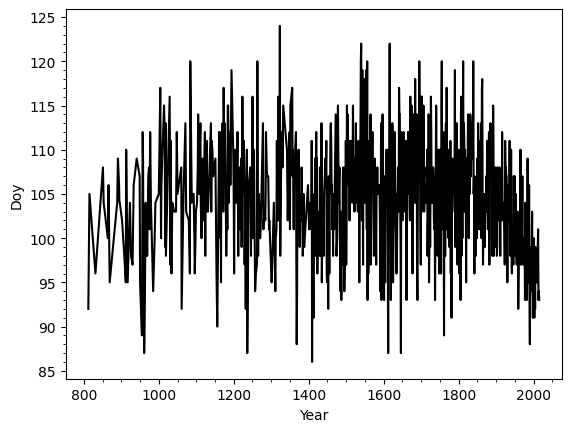

In [21]:
plt.plot(date_doy,doy,'k') #plot the data
plt.xlabel('Year') #label the x-axis
plt.ylabel('Doy') #label the y-axis
plt.minorticks_on() #add minorticks to the plot


/tmp/ipykernel_1941/876280839.py:2: RankWarning: Polyfit may be poorly conditioned
  pp = np.polyfit(date_doy,doy,order) #fit the polynomial, pp will contain the polynomial coefficients


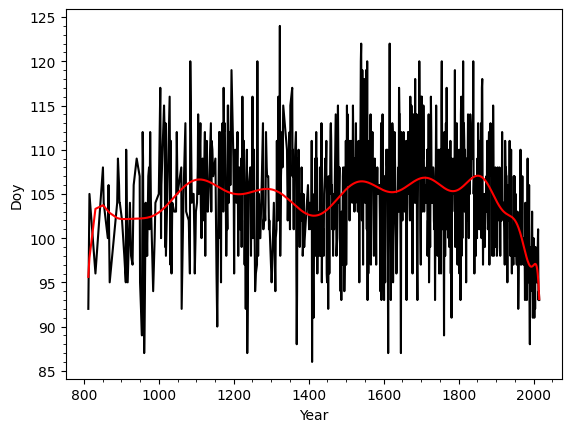

In [34]:
order = 40 #set the polynomial order
pp = np.polyfit(date_doy,doy,order) #fit the polynomial, pp will contain the polynomial coefficients
trend = np.polyval(pp,date_doy) #find the value of the polynomial at each time point.

plt.plot(date_doy,doy,'k') #plot the data
plt.plot(date_doy,trend,'r') #plot the trend
plt.xlabel('Year') #label the x-axis
plt.ylabel('Doy') #label the y-axis
plt.minorticks_on() #add minorticks to the plot

In [35]:
def moving_average(year, doy):
    return np.convolve(year, np.ones(doy), 'valid') / doy

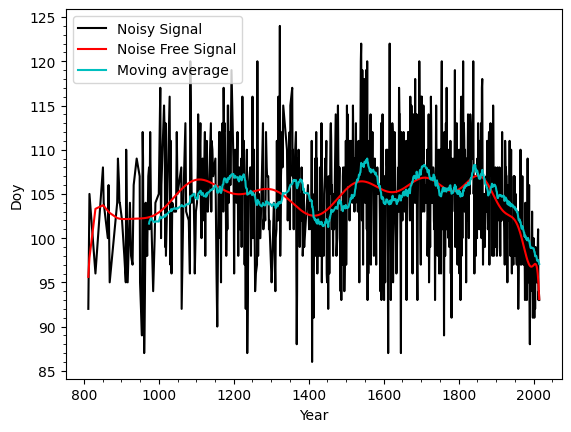

In [37]:
plt.plot(date_doy,doy,'k', label='Noisy Signal') #plot the noisy data
plt.plot(date_doy,trend,'r', label='Noise Free Signal') #plot the trendnoise free signnal

# Calculate a moving average
window_size = 39 # Define a window size for the moving average
moving_avg_doy = np.convolve(doy, np.ones(window_size)/window_size, mode='valid')
# The x-axis for the moving average should be adjusted due to 'valid' convolution mode
date_doy_ma = date_doy[window_size - 1:]

plt.plot(date_doy_ma, moving_avg_doy,'c',label='Moving average') #plot the moving average
plt.xlabel('Year') #label the x-axis
plt.ylabel('Doy') #label the y-axis
plt.legend() #add a legend
plt.minorticks_on() #add minorticks